In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

In [39]:
analysis = pd.read_csv('/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/Assignments/PAC/Data/analysis_data.csv')
scoring = pd.read_csv('/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/Assignments/PAC/Data/scoring_data.csv')

In [4]:
print("Training Data Sample:")
print(analysis.head())

Training Data Sample:
   customer_id  age  gender marital_status education_level     region  \
0     75570383   77  female        married     high school  northeast   
1     77915507   52    male        married     high school      south   
2     31958910   48  female        married       bachelors       west   
3     76868487   67  female        married     high school  northeast   
4     69435006   21  female         single       bachelors       west   

  employment_status  owns_home  has_auto_loan  annual_income  ...  card_type  \
0        unemployed          1              0   56000.116893  ...   standard   
1        unemployed          1              1   39432.589311  ...       gold   
2        unemployed          1              1   51020.949673  ...   standard   
3        unemployed          1              0   76794.566399  ...   standard   
4     self-employed          1              1   44386.444631  ...   standard   

   num_transactions  avg_transaction_value online_shopping

In [5]:
# Check for missing values in the training data
missing_data = analysis.isnull().sum().sort_values(ascending=False)
print("Missing Values in Training Data:")
print(missing_data.head(10))

Missing Values in Training Data:
online_shopping_freq     2008
education_level          1199
utility_payment_count     798
customer_id                 0
tenure                      0
num_credit_cards            0
num_children                0
travel_frequency            0
reward_points_balance       0
avg_transaction_value       0
dtype: int64


In [6]:
# Handling missing values:
# For numerical columns, we can fill missing values with the median
analysis['online_shopping_freq'] = analysis['online_shopping_freq'].fillna(analysis['online_shopping_freq'].median())
analysis['utility_payment_count'] = analysis['utility_payment_count'].fillna(analysis['utility_payment_count'].median())

# For categorical columns, fill missing values with the mode (most frequent value)
edu_mode = analysis['education_level'].mode(dropna=True)
edu_fill = edu_mode.iloc[0] if len(edu_mode) else 'Unknown'
analysis['education_level'] = analysis['education_level'].fillna(edu_fill)

In [7]:
# Check missing values again to ensure no remaining
missing_data_after = analysis.isnull().sum().sort_values(ascending=False)
print("\nMissing Values After Handling:")
print(missing_data_after.head(10))


Missing Values After Handling:
customer_id              0
tenure                   0
num_credit_cards         0
num_children             0
utility_payment_count    0
travel_frequency         0
reward_points_balance    0
online_shopping_freq     0
avg_transaction_value    0
num_transactions         0
dtype: int64


In [8]:
# Define the list of categorical and numerical columns
categorical_cols = ['gender', 'marital_status', 'education_level', 'region', 'employment_status', 'card_type']
numerical_cols = analysis.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove the target column 'monthly_spend' from numerical columns
numerical_cols = [col for col in numerical_cols if col != 'monthly_spend']

# Define preprocessing for both numerical and categorical features
# For categorical: OneHotEncoder for one-hot encoding
# For numerical: StandardScaler for scaling numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),  # Scale numerical features
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)  # OneHotEncode categorical features
    ])

# Preview the preprocessing steps
print("Numerical Features to Scale:", numerical_cols)
print("Categorical Features to Encode:", categorical_cols)

Numerical Features to Scale: ['customer_id', 'age', 'owns_home', 'has_auto_loan', 'annual_income', 'credit_score', 'credit_limit', 'tenure', 'num_transactions', 'avg_transaction_value', 'online_shopping_freq', 'reward_points_balance', 'travel_frequency', 'utility_payment_count', 'num_children', 'num_credit_cards']
Categorical Features to Encode: ['gender', 'marital_status', 'education_level', 'region', 'employment_status', 'card_type']


In [13]:
# Ensure 'customer_id' and 'monthly_spend' are dropped correctly
X = analysis.drop(columns=['monthly_spend', 'customer_id'])  # Drop target and customer_id

# Check and print the columns in X to confirm
print("Columns in X:", X.columns.tolist())  # Print columns in X


Columns in X: ['age', 'gender', 'marital_status', 'education_level', 'region', 'employment_status', 'owns_home', 'has_auto_loan', 'annual_income', 'credit_score', 'credit_limit', 'tenure', 'card_type', 'num_transactions', 'avg_transaction_value', 'online_shopping_freq', 'reward_points_balance', 'travel_frequency', 'utility_payment_count', 'num_children', 'num_credit_cards']


In [14]:
# Create dummy variables for categorical columns
X_with_dummies = pd.get_dummies(X, columns=['gender', 'marital_status', 'education_level', 
                                             'region', 'employment_status', 'card_type'], drop_first=True)

# Check the columns after creating dummies
print("Columns after creating dummies:", X_with_dummies.columns.tolist())

# Split the data into training and testing sets again
X_train, X_test, y_train, y_test = train_test_split(X_with_dummies, y, test_size=0.3, random_state=2101)

# Check the shape of the data after creating dummies
print("Shape of the data after creating dummies:", X_train.shape)

Columns after creating dummies: ['age', 'owns_home', 'has_auto_loan', 'annual_income', 'credit_score', 'credit_limit', 'tenure', 'num_transactions', 'avg_transaction_value', 'online_shopping_freq', 'reward_points_balance', 'travel_frequency', 'utility_payment_count', 'num_children', 'num_credit_cards', 'gender_male', 'marital_status_single', 'education_level_graduate', 'education_level_high school', 'region_northeast', 'region_south', 'region_west', 'employment_status_self-employed', 'employment_status_student', 'employment_status_unemployed', 'card_type_platinum', 'card_type_standard']
Shape of the data after creating dummies: (28000, 27)


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Create the model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate MSE and then take the square root to get RMSE
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print the RMSE
print(f"Root Mean Squared Error (RMSE) on the Test Set: {rmse:.2f}")

Root Mean Squared Error (RMSE) on the Test Set: 257.06


In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Create the Random Forest model
rf_model = RandomForestRegressor(random_state=2101)

# Train the Random Forest model
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Calculate MSE and then take the square root to get RMSE
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

# Print the RMSE for the Random Forest model
print(f"Root Mean Squared Error (RMSE) for Random Forest on the Test Set: {rmse_rf:.2f}")

Root Mean Squared Error (RMSE) for Random Forest on the Test Set: 275.66


In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Define the Random Forest model
rf_model = RandomForestRegressor(random_state=2101)

# Set up the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [10, 20, None],       # Maximum depth of each tree
    'min_samples_split': [2, 5, 10],   # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4]      # Minimum samples required to be at a leaf node
}

# Create the GridSearchCV object
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, 
                           cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

# Fit the model to the data
grid_search.fit(X_train, y_train)

# Print the best parameters found by GridSearchCV
print("Best Parameters from GridSearchCV:", grid_search.best_params_)

# Predict with the best model found
y_pred_rf_tuned = grid_search.best_estimator_.predict(X_test)

# Calculate RMSE for the tuned Random Forest model
mse_rf_tuned = mean_squared_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mse_rf_tuned)

# Print the RMSE of the tuned model
print(f"Root Mean Squared Error (RMSE) for Tuned Random Forest on the Test Set: {rmse_rf_tuned:.2f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits


/opt/anaconda3/envs/pred_env/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters from GridSearchCV: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Root Mean Squared Error (RMSE) for Tuned Random Forest on the Test Set: 274.82


In [19]:
##LINEAR WITH FEATURE ENGINEERING

In [23]:
# Display the first few rows and column names of the original X dataframe
print("Original Columns in X:")
print(X.columns.tolist())

# Check the first few rows to make sure the data looks as expected
print("\nFirst few rows of X:")
print(X.head())

Original Columns in X:
['age', 'gender', 'marital_status', 'education_level', 'region', 'employment_status', 'owns_home', 'has_auto_loan', 'annual_income', 'credit_score', 'credit_limit', 'tenure', 'card_type', 'num_transactions', 'avg_transaction_value', 'online_shopping_freq', 'reward_points_balance', 'travel_frequency', 'utility_payment_count', 'num_children', 'num_credit_cards', 'age_annual_income', 'credit_score_transactions', 'age', 'annual_income', 'credit_score', 'num_transactions', 'age^2', 'age annual_income', 'age credit_score', 'age num_transactions', 'annual_income^2', 'annual_income credit_score', 'annual_income num_transactions', 'credit_score^2', 'credit_score num_transactions', 'num_transactions^2']

First few rows of X:
   age  gender marital_status education_level     region employment_status  \
0   77  female        married     high school  northeast        unemployed   
1   52    male        married     high school      south        unemployed   
2   48  female    

In [24]:
# Drop duplicate columns (if any)
X_encoded = X_encoded.loc[:, ~X_encoded.columns.duplicated()]

# Check the new columns after dropping duplicates
print("\nColumns after cleaning up:")
print(X_encoded.columns.tolist())

# Check the first few rows after cleaning up
print("\nFirst few rows after cleaning up:")
print(X_encoded.head())


Columns after cleaning up:
['age', 'owns_home', 'has_auto_loan', 'annual_income', 'credit_score', 'credit_limit', 'tenure', 'num_transactions', 'avg_transaction_value', 'online_shopping_freq', 'reward_points_balance', 'travel_frequency', 'utility_payment_count', 'num_children', 'num_credit_cards', 'age_annual_income', 'credit_score_transactions', 'age^2', 'age annual_income', 'age credit_score', 'age num_transactions', 'annual_income^2', 'annual_income credit_score', 'annual_income num_transactions', 'credit_score^2', 'credit_score num_transactions', 'num_transactions^2', 'gender_male', 'marital_status_single', 'education_level_graduate', 'education_level_high school', 'region_northeast', 'region_south', 'region_west', 'employment_status_self-employed', 'employment_status_student', 'employment_status_unemployed', 'card_type_platinum', 'card_type_standard']

First few rows after cleaning up:
   age  owns_home  has_auto_loan  annual_income  credit_score  credit_limit  \
0   77          

In [25]:
# Check for missing values in the encoded data
missing_data = X_encoded.isnull().sum()

# Display columns with missing values
print("Missing Values in Features:")
print(missing_data[missing_data > 0])

# Optionally, handle missing values:
# Option 1: Drop rows with missing values
# X_encoded = X_encoded.dropna()

# Option 2: Impute missing values (for numerical columns) using the median
X_encoded = X_encoded.fillna(X_encoded.median())

# Check again to ensure there are no missing values
missing_data_after = X_encoded.isnull().sum()
print("\nMissing Values After Handling:")
print(missing_data_after[missing_data_after > 0])

Missing Values in Features:
Series([], dtype: int64)

Missing Values After Handling:
Series([], dtype: int64)


In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Split the cleaned and engineered data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=2101)

# Create the Linear Regression model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate RMSE for the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print the RMSE for the updated model
print(f"Root Mean Squared Error (RMSE) for Linear Regression after Feature Engineering: {rmse:.2f}")

Root Mean Squared Error (RMSE) for Linear Regression after Feature Engineering: 257.49


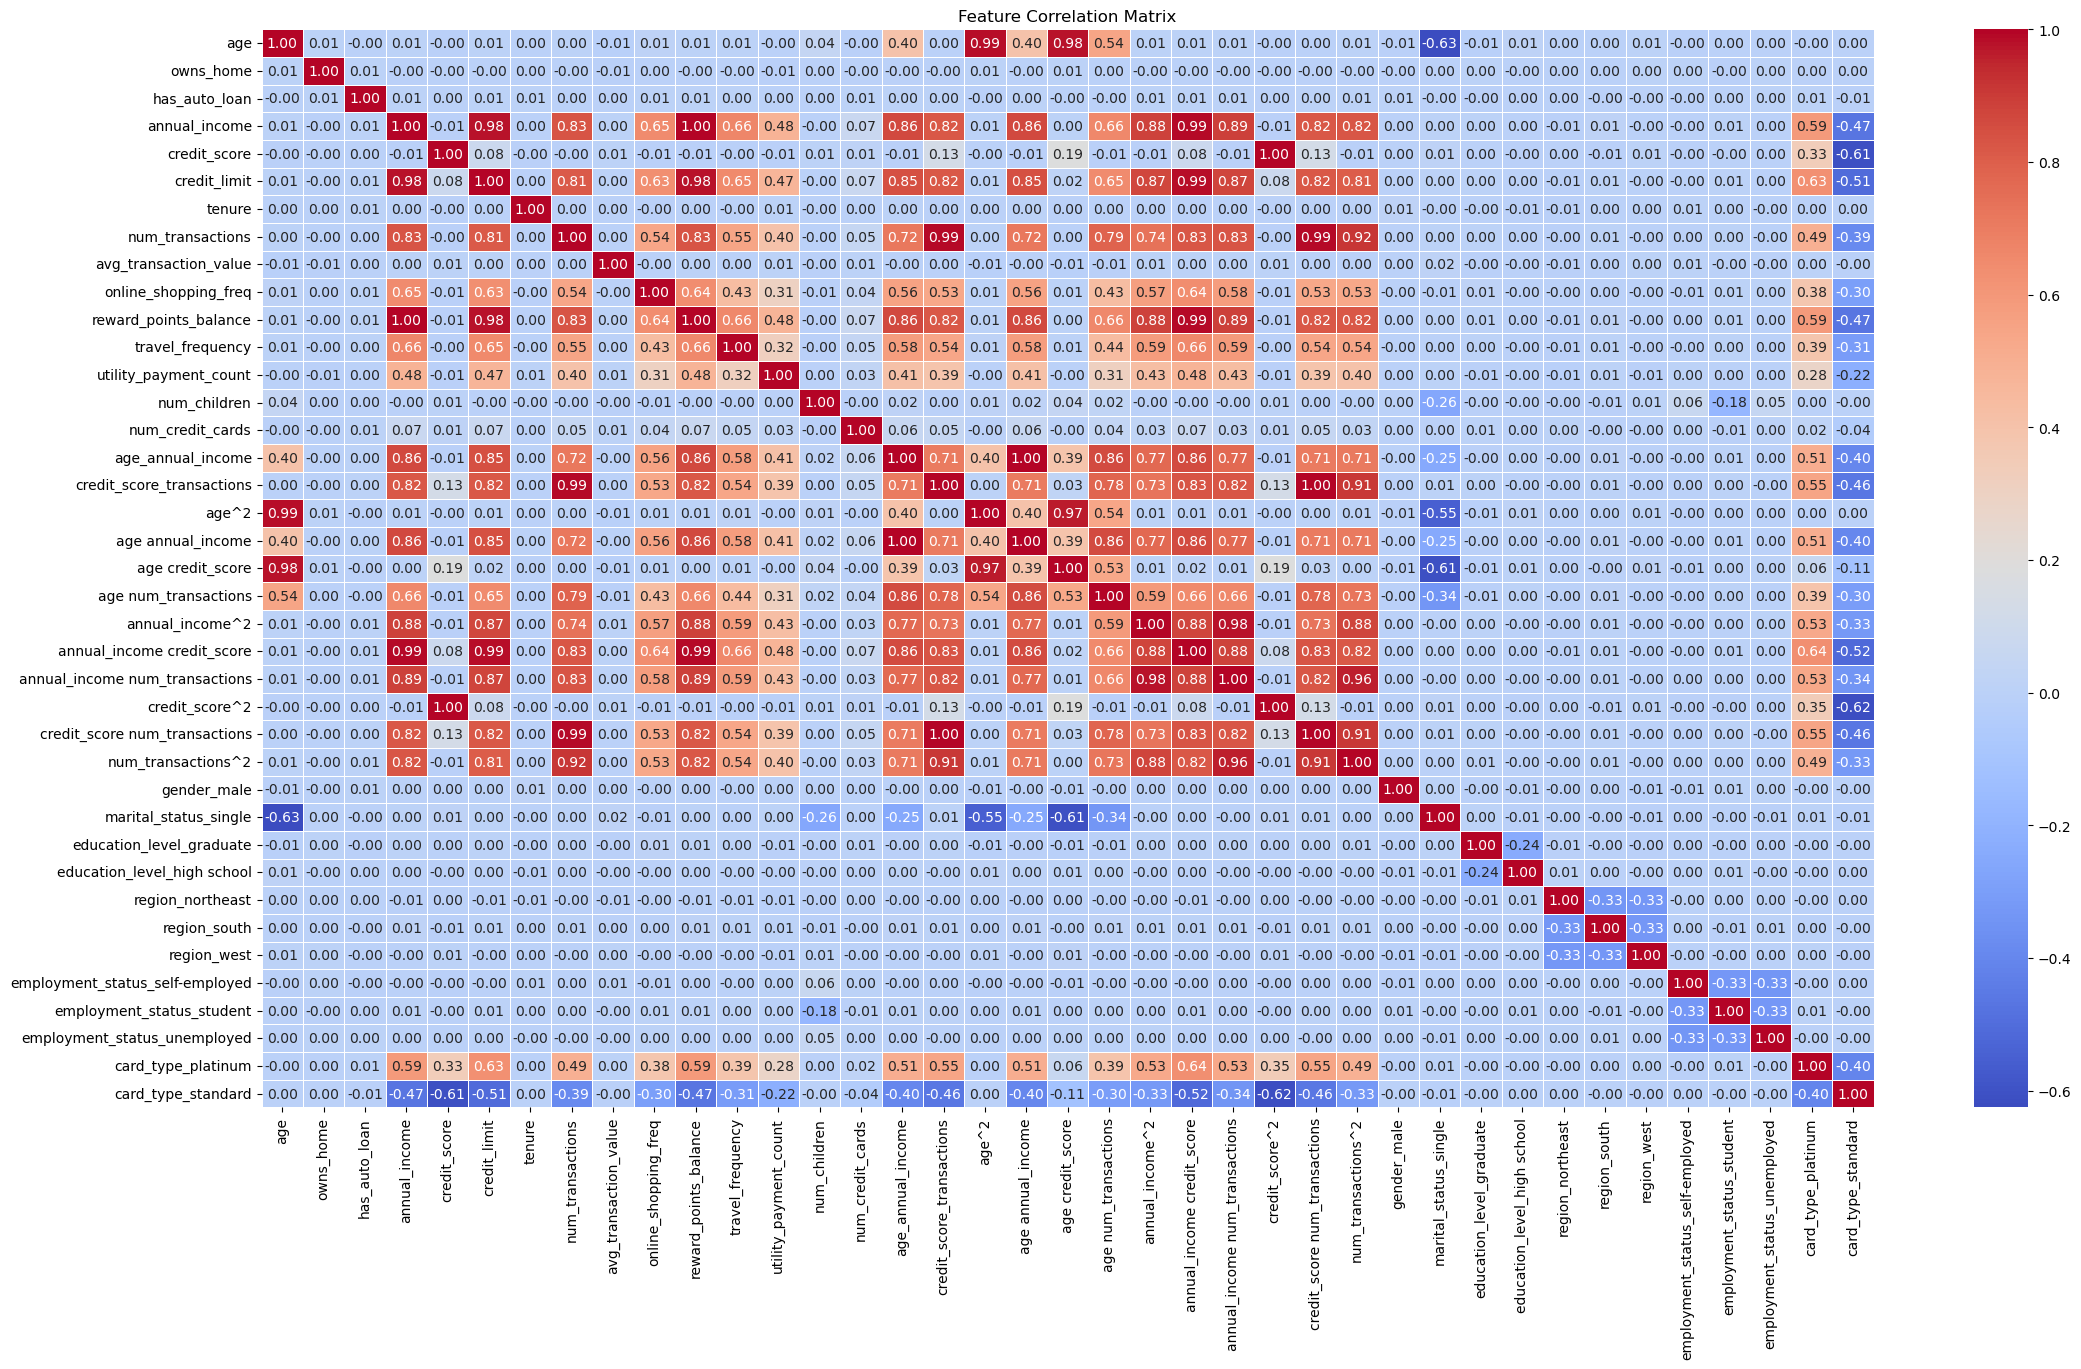

Highly Correlated Features (correlation > 0.9):
                         Feature 1                       Feature 2  \
0                              age                           age^2   
1                              age                age credit_score   
2                    annual_income                    credit_limit   
3                    annual_income           reward_points_balance   
4                    annual_income      annual_income credit_score   
5                     credit_score                  credit_score^2   
6                     credit_limit                   annual_income   
7                     credit_limit           reward_points_balance   
8                     credit_limit      annual_income credit_score   
9                 num_transactions       credit_score_transactions   
10                num_transactions   credit_score num_transactions   
11                num_transactions              num_transactions^2   
12           reward_points_balance        

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = X_encoded.corr()

# Plot the heatmap for better visualization
plt.figure(figsize=(26, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

# Identify highly correlated features (threshold > 0.9)
high_correlation = correlation_matrix[(correlation_matrix > 0.9) & (correlation_matrix != 1)].stack().reset_index()
high_correlation.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Display the pairs of features with high correlation
print("Highly Correlated Features (correlation > 0.9):")
print(high_correlation)

In [32]:
# Remove the correlated features from the list
# Drop features based on correlation analysis (you can adjust this based on your findings)
X_cleaned = X_encoded.drop(columns=['age^2', 'annual_income^2', 'credit_score^2', 'num_transactions^2'])

# Check the new shape of the data
print("\nColumns after removing highly correlated features:")
print(X_cleaned.columns.tolist())

# Now split the cleaned data into training and test sets again
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y, test_size=0.3, random_state=2101)

# Create and train the Linear Regression model again
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate RMSE for the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print the RMSE for the cleaned model
print(f"Root Mean Squared Error (RMSE) for Linear Regression after Removing Highly Correlated Features: {rmse:.2f}")


Columns after removing highly correlated features:
['age', 'owns_home', 'has_auto_loan', 'annual_income', 'credit_score', 'credit_limit', 'tenure', 'num_transactions', 'avg_transaction_value', 'online_shopping_freq', 'reward_points_balance', 'travel_frequency', 'utility_payment_count', 'num_children', 'num_credit_cards', 'age_annual_income', 'credit_score_transactions', 'age annual_income', 'age credit_score', 'age num_transactions', 'annual_income credit_score', 'annual_income num_transactions', 'credit_score num_transactions', 'gender_male', 'marital_status_single', 'education_level_graduate', 'education_level_high school', 'region_northeast', 'region_south', 'region_west', 'employment_status_self-employed', 'employment_status_student', 'employment_status_unemployed', 'card_type_platinum', 'card_type_standard']
Root Mean Squared Error (RMSE) for Linear Regression after Removing Highly Correlated Features: 257.42


In [33]:
##Random Forest Reg

In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Create a Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=2101)

# Train the model on the training data
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Calculate RMSE for the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

# Print the RMSE for the Random Forest model
print(f"Root Mean Squared Error (RMSE) for Random Forest on the Test Set: {rmse_rf:.2f}")

Root Mean Squared Error (RMSE) for Random Forest on the Test Set: 275.83


In [35]:
#Gradient boosting

In [36]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Create the Gradient Boosting Regressor model
gb_model = GradientBoostingRegressor(random_state=2101)

# Train the model on the training data
gb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_gb = gb_model.predict(X_test)

# Calculate RMSE for the model
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)

# Print the RMSE for the Gradient Boosting model
print(f"Root Mean Squared Error (RMSE) for Gradient Boosting on the Test Set: {rmse_gb:.2f}")

Root Mean Squared Error (RMSE) for Gradient Boosting on the Test Set: 261.25


In [37]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Define the hyperparameter grid for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],  # Number of trees
    'learning_rate': [0.01, 0.05, 0.1, 0.2],    # Step size
    'max_depth': [3, 5, 7, 10],                  # Maximum depth of the trees
    'min_samples_split': [2, 5, 10],              # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4],                # Minimum samples required at a leaf node
}

# Create the Gradient Boosting model
gb_model = GradientBoostingRegressor(random_state=2101)

# Set up RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(estimator=gb_model, param_distributions=param_dist, 
                                   n_iter=50, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1, random_state=2101)

# Fit RandomizedSearchCV on the training data
random_search.fit(X_train, y_train)

# Get the best hyperparameters and the best model
print("Best Hyperparameters:", random_search.best_params_)

# Predict with the best model
y_pred_gb_tuned = random_search.best_estimator_.predict(X_test)

# Calculate RMSE for the tuned model
mse_gb_tuned = mean_squared_error(y_test, y_pred_gb_tuned)
rmse_gb_tuned = np.sqrt(mse_gb_tuned)

# Print the RMSE for the tuned Gradient Boosting model
print(f"Root Mean Squared Error (RMSE) for Tuned Gradient Boosting on the Test Set: {rmse_gb_tuned:.2f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Hyperparameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 3, 'learning_rate': 0.05}
Root Mean Squared Error (RMSE) for Tuned Gradient Boosting on the Test Set: 255.15


In [45]:
##CSV FILE CREATION FOR SUB5

In [63]:
# Step 1: Check for missing values in the scoring data
missing_values = scoring_data_encoded.isnull().sum()

# Print the columns that have missing values and how many missing values they have
print(missing_values[missing_values > 0])

online_shopping_freq     492
utility_payment_count    202
dtype: int64


In [64]:
from sklearn.impute import SimpleImputer

# Step 2: Impute missing values in the scoring data
imputer = SimpleImputer(strategy='mean')  # We use 'mean' to fill missing values with the mean of each column

# Fit the imputer on the scoring data and transform the data
scoring_data_imputed = imputer.fit_transform(scoring_data_encoded)

# Convert the imputed array back to a DataFrame with the original column names
scoring_data_imputed = pd.DataFrame(scoring_data_imputed, columns=scoring_data_encoded.columns)

# Check if there are any missing values left
print(scoring_data_imputed.isnull().sum())

age                                0
owns_home                          0
has_auto_loan                      0
annual_income                      0
credit_score                       0
credit_limit                       0
tenure                             0
num_transactions                   0
avg_transaction_value              0
online_shopping_freq               0
reward_points_balance              0
travel_frequency                   0
utility_payment_count              0
num_children                       0
num_credit_cards                   0
age_annual_income                  0
credit_score_transactions          0
age^2                              0
age annual_income                  0
age credit_score                   0
age num_transactions               0
annual_income^2                    0
annual_income credit_score         0
annual_income num_transactions     0
credit_score^2                     0
credit_score num_transactions      0
num_transactions^2                 0
g

In [65]:
# Step 3: Ensure the scoring data has the same columns as the training data
scoring_data_imputed = scoring_data_imputed[required_columns]

# Step 4: Make predictions using the tuned Gradient Boosting model
scoring_predictions = random_search.best_estimator_.predict(scoring_data_imputed)

# Prepare the submission file
submission = pd.DataFrame({
    'customer_id': scoring['customer_id'],  # Assuming 'customer_id' is in the scoring data
    'monthly_spend': scoring_predictions
})

# Save the predictions to the CSV file
submission_file_path = '/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/Assignments/PAC/Codes/Submission_5_gradient_boosting.csv'
submission.to_csv(submission_file_path, index=False)

# Output the path for downloading the submission file
submission_file_path

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- age^2
- annual_income^2
- credit_score^2
- num_transactions^2


In [62]:
# Step 3: Apply preprocessing to scoring data (same as we did for training data)
scoring_data_encoded = pd.get_dummies(scoring, columns=['gender', 'marital_status', 'education_level', 
                                                        'region', 'employment_status', 'card_type'], drop_first=True)

# Generate interaction terms and polynomial features
scoring_data_encoded['age_annual_income'] = scoring_data_encoded['age'] * scoring_data_encoded['annual_income']
scoring_data_encoded['credit_score_transactions'] = scoring_data_encoded['credit_score'] * scoring_data_encoded['num_transactions']
scoring_data_encoded['age^2'] = scoring_data_encoded['age'] ** 2
scoring_data_encoded['annual_income^2'] = scoring_data_encoded['annual_income'] ** 2
scoring_data_encoded['credit_score^2'] = scoring_data_encoded['credit_score'] ** 2

# Step 4: Ensure the scoring data has the same columns as the training data
required_columns = X_encoded.columns  # Use columns from the training data

# If any columns are missing, add them with default value (0)
missing_columns = [col for col in required_columns if col not in scoring_data_encoded.columns]
for col in missing_columns:
    scoring_data_encoded[col] = 0  # Add missing columns with default value 0

# Reorder columns to match the training data
scoring_data_encoded = scoring_data_encoded[required_columns]

# Step 5: Load the best hyperparameters for Gradient Boosting
# These hyperparameters were found from the earlier RandomizedSearchCV
best_params = {
    'n_estimators': 500,
    'min_samples_split': 2,
    'min_samples_leaf': 4,
    'max_depth': 3,
    'learning_rate': 0.05
}

# Step 6: Initialize the Gradient Boosting model with the best hyperparameters
gb_model = GradientBoostingRegressor(**best_params)

# Step 7: Make predictions on the scoring data using the tuned Gradient Boosting model
scoring_predictions = gb_model.predict(scoring_data_encoded)

# Step 8: Prepare the submission file
submission = pd.DataFrame({
    'customer_id': scoring['customer_id'],  # Assuming 'customer_id' is in the scoring data
    'monthly_spend': scoring_predictions
})

# Step 9: Define the path for saving the submission file
submission_file_path = '/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/Assignments/PAC/Codes/Submission_5_gradient_boosting.csv'

# Step 10: Save the predictions to the CSV file
submission.to_csv(submission_file_path, index=False)

# Output the path for downloading the submission file
submission_file_path

/opt/anaconda3/envs/pred_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(


ValueError: Input X contains NaN.
GradientBoostingRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [66]:
# Step 1: Check the features used during training (those should match the scoring data)
print("Columns used for training (X_encoded):")
print(X_encoded.columns)

Columns used for training (X_encoded):
Index(['age', 'owns_home', 'has_auto_loan', 'annual_income', 'credit_score',
       'credit_limit', 'tenure', 'num_transactions', 'avg_transaction_value',
       'online_shopping_freq', 'reward_points_balance', 'travel_frequency',
       'utility_payment_count', 'num_children', 'num_credit_cards',
       'age_annual_income', 'credit_score_transactions', 'age^2',
       'age annual_income', 'age credit_score', 'age num_transactions',
       'annual_income^2', 'annual_income credit_score',
       'annual_income num_transactions', 'credit_score^2',
       'credit_score num_transactions', 'num_transactions^2', 'gender_male',
       'marital_status_single', 'education_level_graduate',
       'education_level_high school', 'region_northeast', 'region_south',
       'region_west', 'employment_status_self-employed',
       'employment_status_student', 'employment_status_unemployed',
       'card_type_platinum', 'card_type_standard'],
      dtype='object')

In [67]:
# Step 2: One-hot encode categorical features in the scoring data
scoring_data_encoded = pd.get_dummies(scoring, columns=['gender', 'marital_status', 'education_level', 
                                                        'region', 'employment_status', 'card_type'], drop_first=True)

# Step 3: Apply the same feature engineering used during training on the scoring data
# Interaction terms and polynomial features (same as in training)
scoring_data_encoded['age_annual_income'] = scoring_data_encoded['age'] * scoring_data_encoded['annual_income']
scoring_data_encoded['credit_score_transactions'] = scoring_data_encoded['credit_score'] * scoring_data_encoded['num_transactions']
scoring_data_encoded['age^2'] = scoring_data_encoded['age'] ** 2
scoring_data_encoded['annual_income^2'] = scoring_data_encoded['annual_income'] ** 2
scoring_data_encoded['credit_score^2'] = scoring_data_encoded['credit_score'] ** 2
scoring_data_encoded['num_transactions^2'] = scoring_data_encoded['num_transactions'] ** 2
scoring_data_encoded['age annual_income'] = scoring_data_encoded['age'] * scoring_data_encoded['annual_income']
scoring_data_encoded['age credit_score'] = scoring_data_encoded['age'] * scoring_data_encoded['credit_score']
scoring_data_encoded['age num_transactions'] = scoring_data_encoded['age'] * scoring_data_encoded['num_transactions']
scoring_data_encoded['annual_income credit_score'] = scoring_data_encoded['annual_income'] * scoring_data_encoded['credit_score']
scoring_data_encoded['annual_income num_transactions'] = scoring_data_encoded['annual_income'] * scoring_data_encoded['num_transactions']
scoring_data_encoded['credit_score num_transactions'] = scoring_data_encoded['credit_score'] * scoring_data_encoded['num_transactions']

In [68]:
# Step 1: Ensure the scoring data has the same columns as the training data
required_columns = X_encoded.columns  # Columns used during training

# Step 2: If any columns are missing, impute them with the mean of the training data
# Get the mean of the columns from the training data
imputed_values = X_encoded.mean()  # Using mean for imputation (can also use median)

# Add missing columns with the imputed values
for col in required_columns:
    if col not in scoring_data_encoded.columns:
        scoring_data_encoded[col] = imputed_values[col]  # Use training data mean for missing columns

# Reorder columns to match the training data
scoring_data_encoded = scoring_data_encoded[required_columns]

In [70]:
# Make predictions using the tuned Gradient Boosting model
scoring_predictions = random_search.best_estimator_.predict(scoring_data_encoded)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- age^2
- annual_income^2
- credit_score^2
- num_transactions^2


In [71]:
# Step 1: Ensure the model has been properly trained
print("Best model after RandomizedSearchCV:")
print(random_search.best_estimator_)

# Check the best hyperparameters
print("Best hyperparameters:")
print(random_search.best_params_)

Best model after RandomizedSearchCV:
GradientBoostingRegressor(learning_rate=0.05, min_samples_leaf=4,
                          n_estimators=500, random_state=2101)
Best hyperparameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 3, 'learning_rate': 0.05}


In [72]:
# Step 2: Check if columns in scoring data match the training data
print("Columns in scoring data:")
print(scoring_data_encoded.columns)

print("Columns in training data (X_encoded):")
print(X_encoded.columns)

Columns in scoring data:
Index(['age', 'owns_home', 'has_auto_loan', 'annual_income', 'credit_score',
       'credit_limit', 'tenure', 'num_transactions', 'avg_transaction_value',
       'online_shopping_freq', 'reward_points_balance', 'travel_frequency',
       'utility_payment_count', 'num_children', 'num_credit_cards',
       'age_annual_income', 'credit_score_transactions', 'age^2',
       'age annual_income', 'age credit_score', 'age num_transactions',
       'annual_income^2', 'annual_income credit_score',
       'annual_income num_transactions', 'credit_score^2',
       'credit_score num_transactions', 'num_transactions^2', 'gender_male',
       'marital_status_single', 'education_level_graduate',
       'education_level_high school', 'region_northeast', 'region_south',
       'region_west', 'employment_status_self-employed',
       'employment_status_student', 'employment_status_unemployed',
       'card_type_platinum', 'card_type_standard'],
      dtype='object')
Columns in tr

In [73]:
# Step 3: Test predictions with a small subset of scoring data (e.g., first 10 rows)
scoring_data_subset = scoring_data_encoded.head(10)

# Make predictions on this small subset
scoring_predictions_subset = random_search.best_estimator_.predict(scoring_data_subset)

print("Predictions on subset:", scoring_predictions_subset)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- age^2
- annual_income^2
- credit_score^2
- num_transactions^2


In [74]:
# Step 1: Align the scoring data with the training data columns
required_columns = X_encoded.columns  # Columns used during training

# Step 2: If any columns are missing, add them with the mean of the training data
imputed_values = X_encoded.mean()  # Use mean for imputation

# Add missing columns with the imputed values
for col in required_columns:
    if col not in scoring_data_encoded.columns:
        scoring_data_encoded[col] = imputed_values[col]  # Use training data mean for missing columns

# Reorder columns to match the training data
scoring_data_encoded = scoring_data_encoded[required_columns]

# Step 3: Check that the columns in scoring data match the training data
print("Columns in scoring data after matching with training data:")
print(scoring_data_encoded.columns)

Columns in scoring data after matching with training data:
Index(['age', 'owns_home', 'has_auto_loan', 'annual_income', 'credit_score',
       'credit_limit', 'tenure', 'num_transactions', 'avg_transaction_value',
       'online_shopping_freq', 'reward_points_balance', 'travel_frequency',
       'utility_payment_count', 'num_children', 'num_credit_cards',
       'age_annual_income', 'credit_score_transactions', 'age^2',
       'age annual_income', 'age credit_score', 'age num_transactions',
       'annual_income^2', 'annual_income credit_score',
       'annual_income num_transactions', 'credit_score^2',
       'credit_score num_transactions', 'num_transactions^2', 'gender_male',
       'marital_status_single', 'education_level_graduate',
       'education_level_high school', 'region_northeast', 'region_south',
       'region_west', 'employment_status_self-employed',
       'employment_status_student', 'employment_status_unemployed',
       'card_type_platinum', 'card_type_standard'],
 

In [75]:
# Step 1: Test predictions on a small subset of the scoring data (first 10 rows)
scoring_data_subset = scoring_data_encoded.head(10)  # Select the first 10 rows of the scoring data

# Make predictions on this small subset
scoring_predictions_subset = random_search.best_estimator_.predict(scoring_data_subset)

# Print the predictions on the subset
print("Predictions on the subset:")
print(scoring_predictions_subset)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- age^2
- annual_income^2
- credit_score^2
- num_transactions^2


In [76]:
# Step 1: Ensure the scoring data has exactly the same columns as the training data

# Load the scoring data
scoring = pd.read_csv('/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/Assignments/PAC/Data/scoring_data.csv')

# One-hot encode categorical features (same as during training)
scoring_data_encoded = pd.get_dummies(scoring, columns=['gender', 'marital_status', 'education_level', 
                                                        'region', 'employment_status', 'card_type'], drop_first=True)

# Apply feature engineering (same as during training)
scoring_data_encoded['age_annual_income'] = scoring_data_encoded['age'] * scoring_data_encoded['annual_income']
scoring_data_encoded['credit_score_transactions'] = scoring_data_encoded['credit_score'] * scoring_data_encoded['num_transactions']

# Add polynomial features like age^2, annual_income^2, etc.
scoring_data_encoded['age^2'] = scoring_data_encoded['age'] ** 2
scoring_data_encoded['annual_income^2'] = scoring_data_encoded['annual_income'] ** 2
scoring_data_encoded['credit_score^2'] = scoring_data_encoded['credit_score'] ** 2
scoring_data_encoded['num_transactions^2'] = scoring_data_encoded['num_transactions'] ** 2

# Now we need to align the columns of the scoring data to the training data (X_encoded)
required_columns = X_encoded.columns  # Columns used during training

# If any columns are missing, we need to add them with the mean of the training data
imputed_values = X_encoded.mean()  # Using mean for imputation

for col in required_columns:
    if col not in scoring_data_encoded.columns:
        scoring_data_encoded[col] = imputed_values[col]  # Add missing columns with training data mean

# Reorder the columns to match the training data order
scoring_data_encoded = scoring_data_encoded[required_columns]

# Step 2: Check columns after alignment
print("Columns in scoring data after matching with training data:")
print(scoring_data_encoded.columns)

Columns in scoring data after matching with training data:
Index(['age', 'owns_home', 'has_auto_loan', 'annual_income', 'credit_score',
       'credit_limit', 'tenure', 'num_transactions', 'avg_transaction_value',
       'online_shopping_freq', 'reward_points_balance', 'travel_frequency',
       'utility_payment_count', 'num_children', 'num_credit_cards',
       'age_annual_income', 'credit_score_transactions', 'age^2',
       'age annual_income', 'age credit_score', 'age num_transactions',
       'annual_income^2', 'annual_income credit_score',
       'annual_income num_transactions', 'credit_score^2',
       'credit_score num_transactions', 'num_transactions^2', 'gender_male',
       'marital_status_single', 'education_level_graduate',
       'education_level_high school', 'region_northeast', 'region_south',
       'region_west', 'employment_status_self-employed',
       'employment_status_student', 'employment_status_unemployed',
       'card_type_platinum', 'card_type_standard'],
 

In [77]:
# Step 3: Make predictions using the tuned Gradient Boosting model
scoring_predictions = random_search.best_estimator_.predict(scoring_data_encoded)

# Step 4: Prepare the submission file
submission = pd.DataFrame({
    'customer_id': scoring['customer_id'],  # Assuming 'customer_id' is in the scoring data
    'monthly_spend': scoring_predictions
})

# Step 5: Define the path for saving the submission file
submission_file_path = '/mnt/data/gradient_boosting_submission.csv'

# Step 6: Save the predictions to the CSV file
submission.to_csv(submission_file_path, index=False)

# Output the path for downloading the submission file
submission_file_path

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- age^2
- annual_income^2
- credit_score^2
- num_transactions^2


In [79]:
import pandas as pd
import numpy as np

# 1. Handle Missing Values (Same logic as Training Data - Cell 6)
# We fill NaNs in the raw scoring data first so interaction terms don't become NaN
scoring['online_shopping_freq'] = scoring['online_shopping_freq'].fillna(scoring['online_shopping_freq'].median())
scoring['utility_payment_count'] = scoring['utility_payment_count'].fillna(scoring['utility_payment_count'].median())
scoring['education_level'] = scoring['education_level'].fillna(scoring['education_level'].mode()[0])

# 2. One-Hot Encoding
scoring_data_encoded = pd.get_dummies(scoring, columns=['gender', 'marital_status', 'education_level', 
                                                        'region', 'employment_status', 'card_type'], drop_first=True)

# 3. Feature Engineering (Create the interaction terms)
scoring_data_encoded['age_annual_income'] = scoring_data_encoded['age'] * scoring_data_encoded['annual_income']
scoring_data_encoded['credit_score_transactions'] = scoring_data_encoded['credit_score'] * scoring_data_encoded['num_transactions']
scoring_data_encoded['age^2'] = scoring_data_encoded['age'] ** 2
scoring_data_encoded['annual_income^2'] = scoring_data_encoded['annual_income'] ** 2
scoring_data_encoded['credit_score^2'] = scoring_data_encoded['credit_score'] ** 2
scoring_data_encoded['num_transactions^2'] = scoring_data_encoded['num_transactions'] ** 2
scoring_data_encoded['age annual_income'] = scoring_data_encoded['age'] * scoring_data_encoded['annual_income']
scoring_data_encoded['age credit_score'] = scoring_data_encoded['age'] * scoring_data_encoded['credit_score']
scoring_data_encoded['age num_transactions'] = scoring_data_encoded['age'] * scoring_data_encoded['num_transactions']
scoring_data_encoded['annual_income credit_score'] = scoring_data_encoded['annual_income'] * scoring_data_encoded['credit_score']
scoring_data_encoded['annual_income num_transactions'] = scoring_data_encoded['annual_income'] * scoring_data_encoded['num_transactions']
scoring_data_encoded['credit_score num_transactions'] = scoring_data_encoded['credit_score'] * scoring_data_encoded['num_transactions']

# 4. Drop Highly Correlated Features (Matches logic from Cell 32)
# These were removed from X_train, so they must be removed here too
features_to_drop = ['age^2', 'annual_income^2', 'credit_score^2', 'num_transactions^2']
scoring_data_final = scoring_data_encoded.drop(columns=features_to_drop, errors='ignore')

# 5. Column Alignment (Ensure exact match with model)
final_model = random_search.best_estimator_
required_features = final_model.feature_names_in_

# Add missing columns (if any) with 0
for col in required_features:
    if col not in scoring_data_final.columns:
        scoring_data_final[col] = 0

# Reorder columns to match training data perfectly
scoring_data_final = scoring_data_final[required_features]

# 6. Final NaN Check (Safety measure)
# If any NaNs remain (e.g., from new columns), fill them with 0
scoring_data_final = scoring_data_final.fillna(0)

# 7. Predict
scoring_predictions = final_model.predict(scoring_data_final)

# 8. Save Submission
submission = pd.DataFrame({
    'customer_id': scoring['customer_id'],
    'monthly_spend': scoring_predictions
})

submission_file_path = '/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/Assignments/PAC/Codes/Submission_5_gradient_boosting.csv'
submission.to_csv(submission_file_path, index=False)

print(f"Submission file successfully saved to: {submission_file_path}")
print("First 5 predictions:")
print(submission.head())

Submission file successfully saved to: /Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/Assignments/PAC/Codes/Submission_5_gradient_boosting.csv
First 5 predictions:
   customer_id  monthly_spend
0     20451981    1864.793037
1     23251656    2636.568403
2     64082260    1442.809214
3     82505923    2024.418831
4     89981994    1421.195743


In [81]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Define the best parameters you found
best_params = {
    'n_estimators': 500,
    'min_samples_split': 2,
    'min_samples_leaf': 4,
    'max_depth': 3,
    'learning_rate': 0.05
}

# 2. Initialize AND Fit the model
# We create a new instance to ensure it's fresh and trained
print("Training the model...")
gb_model_final = GradientBoostingRegressor(**best_params, random_state=2101)
gb_model_final.fit(X_train, y_train)

# 3. Calculate RMSE on Test Set (Your Validation Metric)
print("Predicting on test set...")
test_predictions = gb_model_final.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

print("-" * 30)
print(f"✅ Test Set RMSE: {test_rmse:.2f}")
print("-" * 30)

# 4. Check Scoring Data (If calculating actual scoring RMSE is possible)
if 'monthly_spend' in scoring.columns:
    # This block only runs if your scoring file has the answers (rare for competitions)
    try:
        true_values = scoring['monthly_spend']
        # Ensure scoring_data_final is defined from the previous step
        scoring_predictions = gb_model_final.predict(scoring_data_final) 
        scoring_rmse = np.sqrt(mean_squared_error(true_values, scoring_predictions))
        print(f"📊 Scoring Data RMSE: {scoring_rmse:.2f}")
    except Exception as e:
        print(f"Could not calculate scoring RMSE: {e}")
else:
    print("ℹ️  'monthly_spend' column is missing from scoring data.")
    print("    (This is normal. Use the Test Set RMSE above as your performance estimate.)")

Training the model...
Predicting on test set...
------------------------------
✅ Test Set RMSE: 255.15
------------------------------
ℹ️  'monthly_spend' column is missing from scoring data.
    (This is normal. Use the Test Set RMSE above as your performance estimate.)
